# SOM as a Nonlinear Projection Method

Kohonen argues that the SOM belongs to the family of **nonlinear projection methods**, alongside multidimensional scaling (MDS) and the Sammon mapping. This notebook tests that claim quantitatively by comparing DBGSOM against three sklearn manifold methods on the Digits dataset.

**Methods compared:** DBGSOM · MDS · Isomap · t-SNE  
**Metrics:** Trustworthiness · Continuity · Runtime


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.manifold import trustworthiness

from dbgsom.SomVQ import SomVQ

## Dataset

The Digits dataset contains 8×8 greyscale images of handwritten digits (0–9), represented as 64-dimensional vectors. With 1797 samples and clear cluster structure it is a standard benchmark for projection quality.


In [7]:
X, y = load_digits(return_X_y=True)
print(f"Shape: {X.shape}  |  Classes: {np.unique(y)}")

Shape: (1797, 64)  |  Classes: [0 1 2 3 4 5 6 7 8 9]


## Train All Methods


In [ ]:
# --- DBGSOM ---
from sklearn.manifold import MDS, TSNE, Isomap

t0 = time.perf_counter()
som = SomVQ(
    random_state=42, n_iter=500, max_neurons=50, verbose=False, spreading_factor=0.99
)
som.fit(X)
t_som = time.perf_counter() - t0

bmu_indices = som.predict(X)
som_coords = np.array([som.neurons_[i] for i in bmu_indices], dtype=float)

# # --- MDS ---
t0 = time.perf_counter()
mds_coords = MDS(
    n_components=2, random_state=42, normalized_stress="auto"
).fit_transform(X)
t_mds = time.perf_counter() - t0

# --- Isomap ---
t0 = time.perf_counter()
isomap_coords = Isomap(n_components=2, n_neighbors=5).fit_transform(X)
t_isomap = time.perf_counter() - t0

# --- t-SNE ---
t0 = time.perf_counter()
tsne_coords = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)
t_tsne = time.perf_counter() - t0

embeddings = {
    "DBGSOM": som_coords,
    "MDS": mds_coords,
    "Isomap": isomap_coords,
    "t-SNE": tsne_coords,
}
runtimes = {"DBGSOM": t_som, "MDS": t_mds, "Isomap": t_isomap, "t-SNE": t_tsne}

print(f"{'Method':<10} {'Runtime (s)':>12}  {'SOM neurons' if False else ''}")
for name, t in runtimes.items():
    extra = f"  ({som.som_.number_of_nodes()} neurons)" if name == "DBGSOM" else ""
    print(f"{name:<10} {t:>12.3f}{extra}")

Method      Runtime (s)  
DBGSOM            0.292  (47 neurons)
MDS             138.516
Isomap            2.181
t-SNE             3.612


## Trustworthiness & Continuity

**Trustworthiness** asks: are the k nearest neighbours in the embedding also close in the original space? (Precision)  
**Continuity** asks: are the k nearest neighbours in the original space also close in the embedding? (Recall)

Both metrics are from Venna & Kaski (2001). Continuity is computed by swapping the roles of `X` and `X_emb` in the trustworthiness formula.


In [13]:
def continuity(X, X_emb, n_neighbors):
    return trustworthiness(X_emb, X, n_neighbors=n_neighbors)


k_values = [5, 10, 20]
rows = []
for name, emb in embeddings.items():
    row = {"Method": name}
    for k in k_values:
        row[f"T (k={k})"] = round(trustworthiness(X, emb, n_neighbors=k), 4)
        row[f"C (k={k})"] = round(continuity(X, emb, n_neighbors=k), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
print(df.to_string())
df

        T (k=5)  C (k=5)  T (k=10)  C (k=10)  T (k=20)  C (k=20)
Method                                                          
DBGSOM   0.9436   0.9450    0.9507    0.9411    0.9514    0.9382
MDS      0.8934   0.9512    0.8927    0.9460    0.8905    0.9400
Isomap   0.8659   0.9795    0.8573    0.9701    0.8512    0.9594
t-SNE    0.9951   0.9920    0.9927    0.9875    0.9887    0.9813


,T (k=5),C (k=5),T (k=10),C (k=10),T (k=20),C (k=20)
Method,,,,,,
DBGSOM,0.9436,0.9450,0.9507,0.9411,0.9514,0.9382
MDS,0.8934,0.9512,0.8927,0.9460,0.8905,0.9400
Isomap,0.8659,0.9795,0.8573,0.9701,0.8512,0.9594
t-SNE,0.9951,0.9920,0.9927,0.9875,0.9887,0.9813


## 2D Scatter Plots

Each point is coloured by its true digit label. The SOM plot uses grid coordinates; overlapping points (multiple samples mapped to the same BMU) are expected.


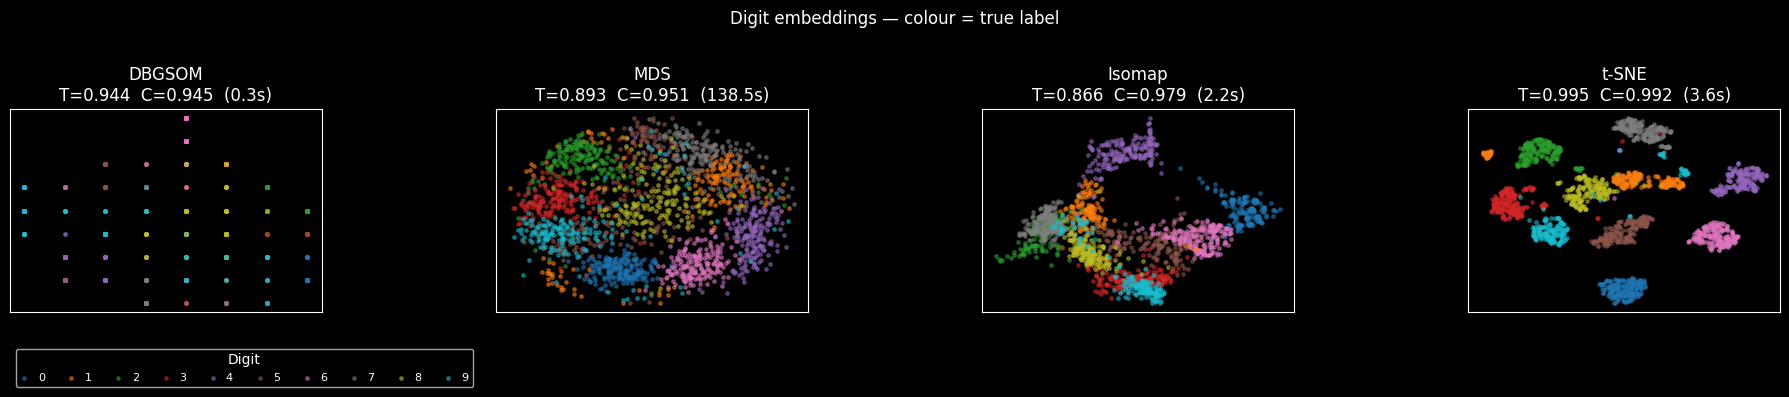

In [14]:
palette = sns.color_palette("tab10", n_colors=10)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, emb) in zip(axes, embeddings.items()):
    for digit in range(10):
        mask = y == digit
        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            color=palette[digit],
            s=6,
            alpha=0.5,
            label=str(digit),
        )
    t5 = trustworthiness(X, emb, n_neighbors=5)
    c5 = continuity(X, emb, n_neighbors=5)
    ax.set_title(f"{name}\nT={t5:.3f}  C={c5:.3f}  ({runtimes[name]:.1f}s)")
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(
    title="Digit",
    bbox_to_anchor=(0, -0.15),
    loc="upper left",
    ncol=10,
    fontsize=8,
    handlelength=0.8,
)
plt.suptitle("Digit embeddings — colour = true label", y=1.02)
plt.tight_layout()
plt.show()

## Runtime Comparison


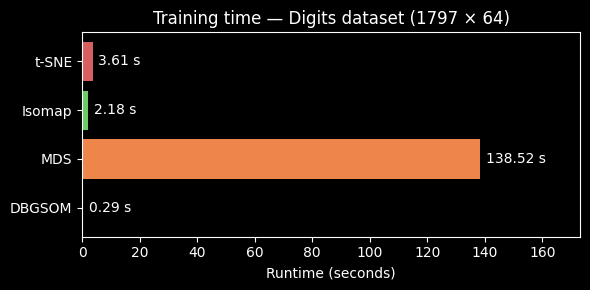

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
names = list(runtimes.keys())
times = list(runtimes.values())
bars = ax.barh(names, times, color=sns.color_palette("muted", len(names)))
ax.bar_label(bars, fmt="%.2f s", padding=4)
ax.set_xlabel("Runtime (seconds)")
ax.set_title("Training time — Digits dataset (1797 × 64)")
ax.set_xlim(0, max(times) * 1.25)
plt.tight_layout()
plt.show()